In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sb
import pandas as pd
import numpy as np
import math 

Mounted at /content/drive


In [ ]:
training = pd.read_csv('/content/drive/MyDrive/dataset-product-backorder/Kaggle_Training_Dataset_v2.csv')
test = pd.read_csv('/content/drive/MyDrive/dataset-product-backorder/Kaggle_Test_Dataset_v2.csv')
dataset = pd.read_csv('/content/drive/MyDrive/kaggle.csv')

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [ ]:
def process(df):
    """
    Some strategies adopted:
    - Binaries were converted from strings ('Yes' and 'No') to 1 and 0.
    - The attributes related to quantities were normalized (std dev equal to 1)
    per row. Therefore, parts with different order of magnitudes are 
    approximated. For example: 1 unit of a expensive machine may be different 
    from 1 unit of a screw, but if we standard deviate all the quantities we 
    have, we can get a better proportion of equivalence between those items.
    - Missing values for lead_time and perf_month_avg were replaced using 
    series median and mean. 
    """
    # Imput missing lines and drop line with problem
    from sklearn.impute import SimpleImputer
    df['lead_time'] = SimpleImputer(strategy='median').fit_transform(
                                    df['lead_time'].values.reshape(-1, 1))
    df = df.dropna()
    for col in ['perf_6_month_avg', 'perf_12_month_avg']:
        df[col] = SimpleImputer(missing_values=-99).fit_transform(
                                    df[col].values.reshape(-1, 1))
    # Convert to binaries
    for col in ['potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk',
               'stop_auto_buy', 'rev_stop', 'went_on_backorder']:
        df[col] = (df[col] == 'Yes').astype(int)
    return df

In [ ]:
#from sklearn.preprocessing import Imputer
df = process(training.append(test))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

In [ ]:
#first 5 entries
df.head(5).transpose()

,0,1,2,3,4
sku,1026827,1043384,1043696,1043852,1044048
national_inv,0,2,2,7,8
lead_time,8,9,8,8,8
in_transit_qty,0,0,0,0,0
forecast_3_month,0,0,0,0,0
forecast_6_month,0,0,0,0,0
forecast_9_month,0,0,0,0,0
sales_1_month,0,0,0,0,0
sales_3_month,0,0,0,0,0
sales_6_month,0,0,0,0,0


In [ ]:
#define quantitative and categorical variable lists 
quantvars=['national_inv',
           'lead_time',
           'in_transit_qty',
           'forecast_3_month',
           'forecast_6_month',
           'forecast_9_month',
           'sales_1_month',
           'sales_3_month',
           'sales_6_month',
           'sales_9_month',
           'min_bank',
           'pieces_past_due',
           'perf_6_month_avg',
           'perf_12_month_avg',
           'local_bo_qty']

catvars=['potential_issue',
            'deck_risk',
            'oe_constraint',
            'ppap_risk',
            'stop_auto_buy',
            'rev_stop',
            'went_on_backorder']

catpred=['potential_issue',
            'deck_risk',
            'oe_constraint',
            'ppap_risk',
            'stop_auto_buy',
            'rev_stop']

In [ ]:
categorical = dataset[catpred]

In [ ]:
y = dataset['went_on_backorder']

In [ ]:
from sklearn.feature_selection import chi2
sel = chi2(categorical, y)

In [ ]:
selected_features = []
for i in range(len(sel[1])):
  if sel[1][i]<0.01:
    selected_features.append(catpred[i])
  print('Feature %s: %f %f' % (catpred[i], sel[1][i], sel[0][i]))

Feature potential_issue: 0.000000 308.399921
Feature deck_risk: 0.000000 245.901043
Feature oe_constraint: 0.000002 22.570713
Feature ppap_risk: 0.000000 119.109984
Feature stop_auto_buy: 0.562565 0.335283
Feature rev_stop: 0.397590 0.715604


In [ ]:
selected_features

['potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk']

In [ ]:
negative=dataset[dataset['went_on_backorder']==0]
positive = dataset[dataset['went_on_backorder']==1]

In [ ]:
selected_quant_features=[]
from scipy.stats import ranksums
for col in quantvars:
  result = ranksums(negative[col], positive[col])
  if result.pvalue< 0.01:
    selected_quant_features.append(col)
  print('Feature %s: %f %f' % (col, result.statistic, result.pvalue))



Feature national_inv: 159.579666 0.000000
Feature lead_time: 28.710642 0.000000
Feature in_transit_qty: 16.935640 0.000000
Feature forecast_3_month: -128.805970 0.000000
Feature forecast_6_month: -127.185743 0.000000
Feature forecast_9_month: -121.787144 0.000000
Feature sales_1_month: -79.670233 0.000000
Feature sales_3_month: -85.739923 0.000000
Feature sales_6_month: -71.051223 0.000000
Feature sales_9_month: -58.867730 0.000000
Feature min_bank: 4.528897 0.000006
Feature pieces_past_due: -14.676370 0.000000
Feature perf_6_month_avg: 26.862180 0.000000
Feature perf_12_month_avg: 27.915226 0.000000
Feature local_bo_qty: -21.640098 0.000000


In [ ]:
selected_quant_features

['national_inv',
 'lead_time',
 'in_transit_qty',
 'forecast_3_month',
 'forecast_6_month',
 'forecast_9_month',
 'sales_1_month',
 'sales_3_month',
 'sales_6_month',
 'sales_9_month',
 'min_bank',
 'pieces_past_due',
 'perf_6_month_avg',
 'perf_12_month_avg',
 'local_bo_qty']

In [ ]:
selected_quant_features=[]
from scipy.stats import ttest_ind
for col in quantvars:
  result = ttest_ind(negative[col], positive[col])
  if result.pvalue< 0.01:
    selected_quant_features.append(col)
  print('%s %f %f' % (col, result.statistic, result.pvalue))

Feature national_inv: 168.926820 0.000000
Feature lead_time: 25.746158 0.000000
Feature in_transit_qty: 17.873855 0.000000
Feature forecast_3_month: -160.100872 0.000000
Feature forecast_6_month: -152.606016 0.000000
Feature forecast_9_month: -138.911557 0.000000
Feature sales_1_month: -103.596243 0.000000
Feature sales_3_month: -101.203329 0.000000
Feature sales_6_month: -77.637756 0.000000
Feature sales_9_month: -64.670420 0.000000
Feature min_bank: 12.888081 0.000000
Feature pieces_past_due: -33.159159 0.000000
Feature perf_6_month_avg: 38.084974 0.000000
Feature perf_12_month_avg: 37.642708 0.000000
Feature local_bo_qty: -71.816521 0.000000


In [ ]:
selected_quant_features

['national_inv',
 'lead_time',
 'in_transit_qty',
 'forecast_3_month',
 'forecast_6_month',
 'forecast_9_month',
 'sales_1_month',
 'sales_3_month',
 'sales_6_month',
 'sales_9_month',
 'min_bank',
 'pieces_past_due',
 'perf_6_month_avg',
 'perf_12_month_avg',
 'local_bo_qty']

In [ ]:
import csv
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
#summary of quantitative variables
df[quantvars].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
national_inv,1929935.0,496.568259,29573.434344,-27256.0,4.00,15.00,80.00,12334404.0
lead_time,1929935.0,7.885898,6.839711,0.0,4.00,8.00,8.00,52.0
in_transit_qty,1929935.0,43.064397,1295.420493,0.0,0.00,0.00,0.00,489408.0
forecast_3_month,1929935.0,178.539864,5108.770174,0.0,0.00,0.00,4.00,1510592.0
forecast_6_month,1929935.0,345.465893,9831.562085,0.0,0.00,0.00,12.00,2461360.0
forecast_9_month,1929935.0,506.606748,14345.430866,0.0,0.00,0.00,20.00,3777304.0
sales_1_month,1929935.0,55.368164,1884.377009,0.0,0.00,0.00,4.00,741774.0
sales_3_month,1929935.0,174.663858,5188.855851,0.0,0.00,1.00,15.00,1105478.0
sales_6_month,1929935.0,341.565349,9585.030376,0.0,0.00,2.00,31.00,2146625.0
sales_9_month,1929935.0,523.577094,14733.265629,0.0,0.00,4.00,47.00,3205172.0


In [ ]:
#---Quantitative variables-----#
#means by backorder status
df.pivot_table(values=quantvars,index=['went_on_backorder']).transpose()

went_on_backorder,0,1
forecast_3_month,178.566740,174.856734
forecast_6_month,345.974100,275.821257
forecast_9_month,507.636728,365.458479
in_transit_qty,43.344159,4.725842
lead_time,7.896724,6.402260
local_bo_qty,0.626744,4.348258
min_bank,52.962026,27.333524
national_inv,500.036607,21.266361
perf_12_month_avg,0.777410,0.706450
perf_6_month_avg,0.782534,0.708870


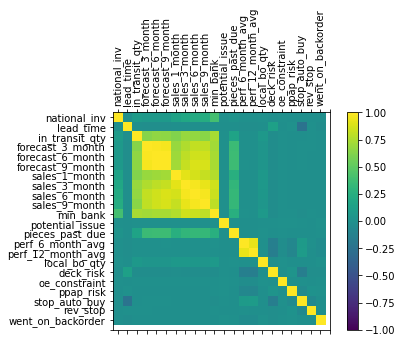

In [ ]:
# Correction Matrix Plot of all variables
varnames=list(training)[1:]    
correlations = df[varnames].corr()
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,23,1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(varnames,rotation=90)
ax.set_yticklabels(varnames)
plt.show()

In [ ]:
correlations

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
national_inv,1.000000,0.003327,0.098473,0.080034,0.081328,0.080423,0.155753,0.191604,0.224305,0.239924,0.405298,0.000243,0.030307,0.002818,0.002061,0.012814,-0.005064,0.000191,-0.000051,-0.003321,-0.000268,-0.001373
lead_time,0.003327,1.000000,-0.006929,-0.007927,-0.008506,-0.008767,-0.005748,-0.006739,-0.007131,-0.007274,-0.007075,-0.005095,-0.001563,-0.011086,-0.008123,-0.001578,0.140587,-0.003133,0.011098,-0.239020,0.001078,-0.018530
in_transit_qty,0.098473,-0.006929,1.000000,0.638241,0.667614,0.661650,0.622062,0.687824,0.676524,0.645470,0.742187,0.007304,0.161349,0.004558,0.001679,0.063223,-0.016224,0.002405,-0.000477,-0.001294,0.000979,-0.002528
forecast_3_month,0.080034,-0.007927,0.638241,1.000000,0.988112,0.971443,0.688490,0.764681,0.817126,0.809634,0.719626,0.007559,0.359632,0.006746,0.003502,0.043872,-0.017078,0.002808,-0.003540,0.002779,0.000448,-0.000062
forecast_6_month,0.081328,-0.008506,0.667614,0.988112,1.000000,0.994281,0.709730,0.799705,0.858822,0.852034,0.736929,0.006819,0.367494,0.007579,0.003879,0.044063,-0.017573,0.002540,-0.003820,0.003404,-0.000121,-0.000605
forecast_9_month,0.080423,-0.008767,0.661650,0.971443,0.994281,1.000000,0.725149,0.823402,0.885969,0.879327,0.735548,0.006627,0.373258,0.007913,0.003959,0.044010,-0.017817,0.002584,-0.003944,0.003552,-0.000317,-0.000841
sales_1_month,0.155753,-0.005748,0.622062,0.688490,0.709730,0.725149,1.000000,0.918282,0.873111,0.824634,0.769847,0.004541,0.260607,0.006426,0.002199,0.065749,-0.014796,0.003450,-0.000878,-0.004807,-0.000535,-0.001170
sales_3_month,0.191604,-0.006739,0.687824,0.764681,0.799705,0.823402,0.918282,1.000000,0.975437,0.930531,0.854285,0.005035,0.314536,0.007008,0.002231,0.068080,-0.017001,0.003649,-0.001162,-0.004977,-0.000578,-0.001486
sales_6_month,0.224305,-0.007131,0.676524,0.817126,0.858822,0.885969,0.873111,0.975437,1.000000,0.973871,0.838836,0.005003,0.334398,0.007195,0.002091,0.056219,-0.018028,0.003722,-0.002134,-0.003073,-0.000544,-0.001727
sales_9_month,0.239924,-0.007274,0.645470,0.809634,0.852034,0.879327,0.824634,0.930531,0.973871,1.000000,0.804336,0.004823,0.329906,0.007489,0.002438,0.048616,-0.018041,0.003584,-0.002710,-0.001959,-0.000552,-0.001776


In [ ]:
    # Normalization    
    from sklearn.preprocessing import normalize
    qty_related = ['national_inv', 'in_transit_qty', 'forecast_3_month', 
                   'forecast_6_month', 'forecast_9_month', 'min_bank',
                   'local_bo_qty', 'pieces_past_due', 'sales_1_month', 
                   'sales_3_month', 'sales_6_month', 'sales_9_month',]
    df[qty_related] = normalize(df[qty_related], axis=1)

In [ ]:
df.head(5).transpose()

,0,1,2,3,4
sku,1026827,1043384,1043696,1043852,1044048
national_inv,0,1,1,0.989949,0.872872
lead_time,8,9,8,8,8
in_transit_qty,0,0,0,0,0
forecast_3_month,0,0,0,0,0
forecast_6_month,0,0,0,0,0
forecast_9_month,0,0,0,0,0
sales_1_month,0,0,0,0,0
sales_3_month,0,0,0,0,0
sales_6_month,0,0,0,0,0


In [ ]:
train=df[ind.isin(train_index)]

In [ ]:
len(result)

1929935

In [ ]:
#create a blank dataframe to fill
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import roc_curve,roc_auc_score, precision_recall_curve, confusion_matrix,accuracy_score
merged_pred=pd.DataFrame(data=None,index=df.index)

#Define folds for  10-fold Cross Validation
kf = KFold(n_splits=10,shuffle=True,random_state=123)  

#Define index of dataset (to help in data sepparations within folds)
ind=df.index

#----------fit models and product predictions in each fold----------#
best_fold_result =[]
for train_index, test_index in kf.split(df):
    #Define Training data
    train=df[ind.isin(train_index)]
    y_train=df['went_on_backorder']
    X_train=df.drop(['sku','went_on_backorder'],axis=1)
    #Define Test data
    test=df[ind.isin(test_index)]
    y_test=df['went_on_backorder']
    X_test=df.drop(['sku','went_on_backorder'],axis=1)
    rf=RandomForestClassifier(n_estimators=50,max_features=3,min_samples_leaf=5)
    rf.fit(X_train,y_train)
    preds=rf.predict_proba(X_test)[:,1]
    rocauc = roc_auc_score(y_test, preds)
    print(rocauc)
    best_fold_result.append(rocauc)

0.9954736714709465
0.9954936436567534
0.9954841251795603
0.995550546526862
0.9955042507796066
0.995482072799797
0.9954973321688608
0.9954523141705213
0.9955036221526746
0.9955004898628471


In [ ]:
best_fold_result

[0.9954736714709465,
 0.9954936436567534,
 0.9954841251795603,
 0.995550546526862,
 0.9955042507796066,
 0.995482072799797,
 0.9954973321688608,
 0.9954523141705213,
 0.9955036221526746,
 0.9955004898628471]